In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<hr style="border: none; height: 15px; background: linear-gradient(to right, #ff6ec7, #ff1493); border-radius: 5px;">

## **Data Reading**

In [2]:
df = pd.read_csv('../Data/Spotify_Youtube.csv')

In [3]:
df.head(3)

,Unnamed: 0,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,...,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07


<hr style="border: none; height: 15px; background: linear-gradient(to right, #ff6ec7, #ff1493); border-radius: 5px;">

## **Data Cleaning**

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20718 entries, 0 to 20717
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        20718 non-null  int64  
 1   Artist            20718 non-null  str    
 2   Url_spotify       20718 non-null  str    
 3   Track             20718 non-null  str    
 4   Album             20718 non-null  str    
 5   Album_type        20718 non-null  str    
 6   Uri               20718 non-null  str    
 7   Danceability      20716 non-null  float64
 8   Energy            20716 non-null  float64
 9   Key               20716 non-null  float64
 10  Loudness          20716 non-null  float64
 11  Speechiness       20716 non-null  float64
 12  Acousticness      20716 non-null  float64
 13  Instrumentalness  20716 non-null  float64
 14  Liveness          20716 non-null  float64
 15  Valence           20716 non-null  float64
 16  Tempo             20716 non-null  float64
 17  Dura

In [5]:
df

,Unnamed: 0,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,...,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07
3,3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On Melancholy Hill,Plastic Beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,0.689,0.739,2.0,...,https://www.youtube.com/watch?v=04mfKJWDSzI,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,Follow Gorillaz online:\nhttp://gorillaz.com \...,True,True,4.346636e+08
4,4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint Eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,0.663,0.694,10.0,...,https://www.youtube.com/watch?v=1V_xRb0x9aw,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,The official music video for Gorillaz - Clint ...,True,True,6.172597e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20713,20713,SICK LEGEND,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,JUST DANCE HARDSTYLE,JUST DANCE HARDSTYLE,single,spotify:track:0RtcKQGyI4hr8FgFH1TuYG,0.582,0.926,5.0,...,https://www.youtube.com/watch?v=5SHmKFKlNqI,JUST DANCE HARDSTYLE,SICK LEGEND - Topic,71678.0,1113.0,0.0,Provided to YouTube by Routenote\n\nJUST DANCE...,True,True,9.227144e+06
20714,20714,SICK LEGEND,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,SET FIRE TO THE RAIN HARDSTYLE,SET FIRE TO THE RAIN HARDSTYLE,single,spotify:track:3rHvPA8lUnPBkaLyPOc0VV,0.531,0.936,4.0,...,https://www.youtube.com/watch?v=ocTH6KxllDQ,SET FIRE TO THE RAIN HARDSTYLE,SICK LEGEND - Topic,164741.0,2019.0,0.0,Provided to YouTube by Routenote\n\nSET FIRE T...,True,True,1.089818e+07
20715,20715,SICK LEGEND,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,OUTSIDE HARDSTYLE SPED UP,OUTSIDE HARDSTYLE SPED UP,single,spotify:track:4jk00YxPtPbhvHJE9N4ddv,0.443,0.830,4.0,...,https://www.youtube.com/watch?v=5wFhE-HY0hg,OUTSIDE HARDSTYLE SPED UP,SICK LEGEND - Topic,35646.0,329.0,0.0,Provided to YouTube by Routenote\n\nOUTSIDE HA...,True,True,6.226110e+06
20716,20716,SICK LEGEND,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,ONLY GIRL HARDSTYLE,ONLY GIRL HARDSTYLE,single,spotify:track:5EyErbpsugWliX006eTDex,0.417,0.767,9.0,...,https://www.youtube.com/watch?v=VMFLbFRNCn0,ONLY GIRL HARDSTYLE,SICK LEGEND - Topic,6533.0,88.0,0.0,Provided to YouTube by Routenote\n\nONLY GIRL ...,True,True,6.873961e+06


### **Drop Unnamed Index Column**

In [6]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [7]:
df.head(2)

,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,Loudness,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,-6.679,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,-5.815,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08


### **Converting Danceability and Energy into Percentage**

In [8]:
df['Danceability'] =df['Danceability']* 100

In [9]:
df['Danceability']

0        81.8
1        67.6
2        69.5
3        68.9
4        66.3
         ... 
20713    58.2
20714    53.1
20715    44.3
20716    41.7
20717    49.8
Name: Danceability, Length: 20718, dtype: float64

In [10]:
df['Energy']=df['Energy'] * 100

In [11]:
df['Energy']

0        70.5
1        70.3
2        92.3
3        73.9
4        69.4
         ... 
20713    92.6
20714    93.6
20715    83.0
20716    76.7
20717    93.8
Name: Energy, Length: 20718, dtype: float64

### **Handle Missing Values**

In [12]:
df.isnull().sum()

Artist                0
Url_spotify           0
Track                 0
Album                 0
Album_type            0
Uri                   0
Danceability          2
Energy                2
Key                   2
Loudness              2
Speechiness           2
Acousticness          2
Instrumentalness      2
Liveness              2
Valence               2
Tempo                 2
Duration_ms           2
Url_youtube         470
Title               470
Channel             470
Views               470
Likes               541
Comments            569
Description         876
Licensed            470
official_video      470
Stream              576
dtype: int64

In [13]:
df_original=df.copy()

In [14]:
df.dropna(subset=['Danceability','Energy','Key','Loudness','Speechiness','Acousticness','Instrumentalness','Liveness','Valence','Tempo','Duration_ms'], inplace=True)

In [15]:
df.isnull().sum()

Artist                0
Url_spotify           0
Track                 0
Album                 0
Album_type            0
Uri                   0
Danceability          0
Energy                0
Key                   0
Loudness              0
Speechiness           0
Acousticness          0
Instrumentalness      0
Liveness              0
Valence               0
Tempo                 0
Duration_ms           0
Url_youtube         469
Title               469
Channel             469
Views               469
Likes               540
Comments            568
Description         875
Licensed            469
official_video      469
Stream              576
dtype: int64

### **Check Duplicates**

In [16]:
df.duplicated().sum()

np.int64(0)

### **Fix Data Types**

In [17]:
df['official_video'].info()

<class 'pandas.Series'>
Index: 20716 entries, 0 to 20717
Series name: official_video
Non-Null Count  Dtype 
--------------  ----- 
20247 non-null  object
dtypes: object(1)
memory usage: 323.7+ KB


In [18]:
df['official_video'] = df['official_video'].astype('bool')

In [19]:
df['official_video'].info()

<class 'pandas.Series'>
Index: 20716 entries, 0 to 20717
Series name: official_video
Non-Null Count  Dtype
--------------  -----
20716 non-null  bool 
dtypes: bool(1)
memory usage: 182.1 KB


In [20]:
df['Licensed'].info()

<class 'pandas.Series'>
Index: 20716 entries, 0 to 20717
Series name: Licensed
Non-Null Count  Dtype 
--------------  ----- 
20247 non-null  object
dtypes: object(1)
memory usage: 323.7+ KB


In [21]:
df['Licensed'] = df['Licensed'].astype('bool')

In [22]:
df['Licensed'].info()

<class 'pandas.Series'>
Index: 20716 entries, 0 to 20717
Series name: Licensed
Non-Null Count  Dtype
--------------  -----
20716 non-null  bool 
dtypes: bool(1)
memory usage: 182.1 KB


### **Clean Description Column**

In [23]:
df['Description'] = df['Description'].str.replace('\n',' ')

In [24]:
df['Description']

0        Official HD Video for Gorillaz' fantastic trac...
1        The official video for Gorillaz - Rhinestone E...
2        Gorillaz - New Gold ft. Tame Impala & Bootie B...
3        Follow Gorillaz online: http://gorillaz.com  h...
4        The official music video for Gorillaz - Clint ...
                               ...                        
20713    Provided to YouTube by Routenote  JUST DANCE H...
20714    Provided to YouTube by Routenote  SET FIRE TO ...
20715    Provided to YouTube by Routenote  OUTSIDE HARD...
20716    Provided to YouTube by Routenote  ONLY GIRL HA...
20717    Provided to YouTube by Routenote  MISS YOU HAR...
Name: Description, Length: 20716, dtype: str

### **Convert Streams into Millions**

In [25]:
df['Stream'] = df['Stream']/1e6

In [26]:
df['Stream']

0        1040.234854
1         310.083733
2          63.063467
3         434.663559
4         617.259738
            ...     
20713       9.227144
20714      10.898176
20715       6.226110
20716       6.873961
20717       5.695584
Name: Stream, Length: 20716, dtype: float64

### **Convert Views into Millions**

In [27]:
df['Views']=df['Views']/1e6

In [28]:
df['Views']

0        693.555221
1         72.011645
2          8.435055
3        211.754952
4        618.480958
            ...    
20713      0.071678
20714      0.164741
20715      0.035646
20716      0.006533
20717      0.158697
Name: Views, Length: 20716, dtype: float64

### **Text Capitalization**

In [29]:
df['Title']=df['Title'].str.capitalize()

In [30]:
df['Title']

0               Gorillaz - feel good inc. (official video)
1        Gorillaz - rhinestone eyes [storyboard film] (...
2        Gorillaz - new gold ft. tame impala & bootie b...
3           Gorillaz - on melancholy hill (official video)
4               Gorillaz - clint eastwood (official video)
                               ...                        
20713                                 Just dance hardstyle
20714                       Set fire to the rain hardstyle
20715                            Outside hardstyle sped up
20716                                  Only girl hardstyle
20717                                   Miss you hardstyle
Name: Title, Length: 20716, dtype: str

In [31]:
df['Artist']=df['Artist'].str.capitalize()

In [32]:
df['Artist']

0           Gorillaz
1           Gorillaz
2           Gorillaz
3           Gorillaz
4           Gorillaz
            ...     
20713    Sick legend
20714    Sick legend
20715    Sick legend
20716    Sick legend
20717    Sick legend
Name: Artist, Length: 20716, dtype: str

In [33]:
df['Track']=df['Track'].str.capitalize()

In [34]:
df['Track']

0                                       Feel good inc.
1                                      Rhinestone eyes
2        New gold (feat. tame impala and bootie brown)
3                                   On melancholy hill
4                                       Clint eastwood
                             ...                      
20713                             Just dance hardstyle
20714                   Set fire to the rain hardstyle
20715                        Outside hardstyle sped up
20716                              Only girl hardstyle
20717                               Miss you hardstyle
Name: Track, Length: 20716, dtype: str

In [35]:
df['Album']=df['Album'].str.capitalize()

In [36]:
df['Album']

0                                           Demon days
1                                        Plastic beach
2        New gold (feat. tame impala and bootie brown)
3                                        Plastic beach
4                                             Gorillaz
                             ...                      
20713                             Just dance hardstyle
20714                   Set fire to the rain hardstyle
20715                        Outside hardstyle sped up
20716                              Only girl hardstyle
20717                               Miss you hardstyle
Name: Album, Length: 20716, dtype: str

In [37]:
df['Channel']=df['Channel'].str.capitalize()

In [38]:
df['Channel']

0                   Gorillaz
1                   Gorillaz
2                   Gorillaz
3                   Gorillaz
4                   Gorillaz
                ...         
20713    Sick legend - topic
20714    Sick legend - topic
20715    Sick legend - topic
20716    Sick legend - topic
20717    Sick legend - topic
Name: Channel, Length: 20716, dtype: str

### **Rename Columns**

In [39]:
df.columns

Index(['Artist', 'Url_spotify', 'Track', 'Album', 'Album_type', 'Uri',
       'Danceability', 'Energy', 'Key', 'Loudness', 'Speechiness',
       'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo',
       'Duration_ms', 'Url_youtube', 'Title', 'Channel', 'Views', 'Likes',
       'Comments', 'Description', 'Licensed', 'official_video', 'Stream'],
      dtype='str')

In [40]:
df.rename(columns={'Uri':'URI_spotify', 'Url_youtube':'URL_youtube','Url_spotify':'URL_spotify', 'Stream':'Streams'}, inplace=True)

In [41]:
df.columns

Index(['Artist', 'URL_spotify', 'Track', 'Album', 'Album_type', 'URI_spotify',
       'Danceability', 'Energy', 'Key', 'Loudness', 'Speechiness',
       'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo',
       'Duration_ms', 'URL_youtube', 'Title', 'Channel', 'Views', 'Likes',
       'Comments', 'Description', 'Licensed', 'official_video', 'Streams'],
      dtype='str')

In [42]:
df

,Artist,URL_spotify,Track,Album,Album_type,URI_spotify,Danceability,Energy,Key,Loudness,...,URL_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Streams
0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel good inc.,Demon days,album,spotify:track:0d28khcov6AiegSCpG5TuT,81.8,70.5,6.0,-6.679,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - feel good inc. (official video),Gorillaz,693.555221,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1040.234854
1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone eyes,Plastic beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,67.6,70.3,8.0,-5.815,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - rhinestone eyes [storyboard film] (...,Gorillaz,72.011645,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,310.083733
2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New gold (feat. tame impala and bootie brown),New gold (feat. tame impala and bootie brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,69.5,92.3,1.0,-3.930,...,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - new gold ft. tame impala & bootie b...,Gorillaz,8.435055,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,63.063467
3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On melancholy hill,Plastic beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,68.9,73.9,2.0,-5.810,...,https://www.youtube.com/watch?v=04mfKJWDSzI,Gorillaz - on melancholy hill (official video),Gorillaz,211.754952,1788577.0,55229.0,Follow Gorillaz online: http://gorillaz.com h...,True,True,434.663559
4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,66.3,69.4,10.0,-8.627,...,https://www.youtube.com/watch?v=1V_xRb0x9aw,Gorillaz - clint eastwood (official video),Gorillaz,618.480958,6197318.0,155930.0,The official music video for Gorillaz - Clint ...,True,True,617.259738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20713,Sick legend,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,Just dance hardstyle,Just dance hardstyle,single,spotify:track:0RtcKQGyI4hr8FgFH1TuYG,58.2,92.6,5.0,-6.344,...,https://www.youtube.com/watch?v=5SHmKFKlNqI,Just dance hardstyle,Sick legend - topic,0.071678,1113.0,0.0,Provided to YouTube by Routenote JUST DANCE H...,True,True,9.227144
20714,Sick legend,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,Set fire to the rain hardstyle,Set fire to the rain hardstyle,single,spotify:track:3rHvPA8lUnPBkaLyPOc0VV,53.1,93.6,4.0,-1.786,...,https://www.youtube.com/watch?v=ocTH6KxllDQ,Set fire to the rain hardstyle,Sick legend - topic,0.164741,2019.0,0.0,Provided to YouTube by Routenote SET FIRE TO ...,True,True,10.898176
20715,Sick legend,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,Outside hardstyle sped up,Outside hardstyle sped up,single,spotify:track:4jk00YxPtPbhvHJE9N4ddv,44.3,83.0,4.0,-4.679,...,https://www.youtube.com/watch?v=5wFhE-HY0hg,Outside hardstyle sped up,Sick legend - topic,0.035646,329.0,0.0,Provided to YouTube by Routenote OUTSIDE HARD...,True,True,6.226110
20716,Sick legend,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,Only girl hardstyle,Only girl hardstyle,single,spotify:track:5EyErbpsugWliX006eTDex,41.7,76.7,9.0,-4.004,...,https://www.youtube.com/watch?v=VMFLbFRNCn0,Only girl hardstyle,Sick legend - topic,0.006533,88.0,0.0,Provided to YouTube by Routenote ONLY GIRL HA...,True,True,6.873961


<hr style="border: none; height: 15px; background: linear-gradient(to right, #ff6ec7, #ff1493); border-radius: 5px;">

## **Data Analysis**

In [43]:
df.head()

,Artist,URL_spotify,Track,Album,Album_type,URI_spotify,Danceability,Energy,Key,Loudness,...,URL_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Streams
0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel good inc.,Demon days,album,spotify:track:0d28khcov6AiegSCpG5TuT,81.8,70.5,6.0,-6.679,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - feel good inc. (official video),Gorillaz,693.555221,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1040.234854
1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone eyes,Plastic beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,67.6,70.3,8.0,-5.815,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - rhinestone eyes [storyboard film] (...,Gorillaz,72.011645,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,310.083733
2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New gold (feat. tame impala and bootie brown),New gold (feat. tame impala and bootie brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,69.5,92.3,1.0,-3.930,...,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - new gold ft. tame impala & bootie b...,Gorillaz,8.435055,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,63.063467
3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On melancholy hill,Plastic beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,68.9,73.9,2.0,-5.810,...,https://www.youtube.com/watch?v=04mfKJWDSzI,Gorillaz - on melancholy hill (official video),Gorillaz,211.754952,1788577.0,55229.0,Follow Gorillaz online: http://gorillaz.com h...,True,True,434.663559
4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,66.3,69.4,10.0,-8.627,...,https://www.youtube.com/watch?v=1V_xRb0x9aw,Gorillaz - clint eastwood (official video),Gorillaz,618.480958,6197318.0,155930.0,The official music video for Gorillaz - Clint ...,True,True,617.259738


In [44]:
df.describe()

,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Views,Likes,Comments,Streams
count,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,2.071600e+04,20247.000000,2.017600e+04,2.014800e+04,20140.000000
mean,61.977745,63.525035,5.300348,-7.671680,0.096456,0.291535,0.055962,0.193521,0.529853,120.638340,2.247176e+05,93.941391,6.633658e+05,2.751997e+04,135.942990
std,16.527239,21.414683,3.576449,4.632749,0.111960,0.286299,0.193262,0.168531,0.245441,29.579018,1.247905e+05,274.650635,1.789365e+06,1.932394e+05,244.144125
min,0.000000,0.002030,0.000000,-46.251000,0.000000,0.000001,0.000000,0.014500,0.000000,0.000000,3.098500e+04,0.000000,0.000000e+00,0.000000e+00,0.006574
25%,51.800000,50.700000,2.000000,-8.858000,0.035700,0.045200,0.000000,0.094100,0.339000,97.002000,1.800095e+05,1.825713,2.157500e+04,5.090000e+02,17.672604
50%,63.700000,66.600000,5.000000,-6.536000,0.050500,0.193000,0.000002,0.125000,0.537000,119.965000,2.132845e+05,14.501095,1.244745e+05,3.277000e+03,49.676981
75%,74.025000,79.800000,8.000000,-4.931000,0.103000,0.477250,0.000463,0.237000,0.726250,139.935000,2.524430e+05,70.399749,5.221765e+05,1.436000e+04,138.352510
max,97.500000,100.000000,11.000000,0.920000,0.964000,0.996000,1.000000,1.000000,0.993000,243.372000,4.676058e+06,8079.649362,5.078865e+07,1.608314e+07,3386.520288


### **Video with Highest Views**

In [45]:
df['Views'].max()

np.float64(8079.649362)

In [46]:
df[df['Views']==df['Views'].max()]

,Artist,URL_spotify,Track,Album,Album_type,URI_spotify,Danceability,Energy,Key,Loudness,...,URL_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Streams
1147,Luis fonsi,https://open.spotify.com/artist/4V8Sr092TqfHkf...,Despacito,Vida,album,spotify:track:6habFhsOp2NvshLv26DqMb,65.5,79.7,2.0,-4.787,...,https://www.youtube.com/watch?v=kJQP7kiw5Fk,Luis fonsi - despacito ft. daddy yankee,Luisfonsivevo,8079.649362,50788652.0,4252791.0,“Despacito” disponible ya en todas las platafo...,True,True,1506.598267


In [47]:
cols=['Artist','Track','Album','Channel','Title','Views','Likes']

In [48]:
df[df['Views']==df['Views'].max()][cols]

,Artist,Track,Album,Channel,Title,Views,Likes
1147,Luis fonsi,Despacito,Vida,Luisfonsivevo,Luis fonsi - despacito ft. daddy yankee,8079.649362,50788652.0


### **Video with Lowest Views**

In [49]:
df['Views'].min()

np.float64(0.0)

In [50]:
df[df['Views']==df['Views'].min()]

,Artist,URL_spotify,Track,Album,Album_type,URI_spotify,Danceability,Energy,Key,Loudness,...,URL_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Streams
5898,Santiago ziesmer,https://open.spotify.com/artist/5isi7xwETQC1Hb...,Kapitel 5.2 & kapitel 6.1 - die kleine hexe - ...,Die kleine hexe - das hörspiel,album,spotify:track:3SiBe9HRopGnuzfl4s2pWw,59.9,24.1,10.0,-17.925,...,https://www.youtube.com/watch?v=z04b-pMl864,Kapitel 5.2 - hundeherz,Various artists - topic,0.0,0.0,0.0,Provided to YouTube by Bookwire Kapitel 5.2 -...,True,True,NaN


In [51]:
df[df['Views']==df['Views'].min()][cols]

,Artist,Track,Album,Channel,Title,Views,Likes
5898,Santiago ziesmer,Kapitel 5.2 & kapitel 6.1 - die kleine hexe - ...,Die kleine hexe - das hörspiel,Various artists - topic,Kapitel 5.2 - hundeherz,0.0,0.0


### **Tracks Only Available on Spotify**

In [52]:
col=['Artist','Track','Album']

In [53]:
spotify_only=df[df['URL_youtube'].isnull()][col]

In [54]:
spotify_only

,Artist,Track,Album
410,Wisin & yandel,Besos moja2,La última misión
411,Wisin & yandel,Mayor que usted,Mayor que usted
412,Wisin & yandel,Vapor,La última misión
413,Wisin & yandel,Si te pillo,Si te pillo
414,Wisin & yandel,Noche de entierro,Mas flow - los benjamins
...,...,...,...
20090,Guilherme & benuto,Pulei na piscina - ao vivo,Drive-in (ao vivo)
20091,Guilherme & benuto,Batom vermelho,Batom vermelho
20092,Guilherme & benuto,Declaração pro bar - ao vivo,"Amando, bebendo e sofrendo (ao vivo) - ep 3"
20093,Fred again..,Rumble,Rumble


### **Top 10 Most Streamed Tracks**

In [55]:
top_10_streams=df.nlargest(10,'Streams')[['Artist','Track','Album','Streams']]

In [56]:
top_10_streams

,Artist,Track,Album,Streams
15250,The weeknd,Blinding lights,After hours,3386.520288
12452,Ed sheeran,Shape of you,÷ (deluxe),3362.005201
19186,Lewis capaldi,Someone you loved,Divinely uninspired to a hellish extent,2634.013335
17937,Post malone,Rockstar (feat. 21 savage),Beerbongs & bentleys,2594.926619
17445,Swae lee,Sunflower - spider-man: into the spider-verse,Hollywood's bleeding,2538.329799
17938,Post malone,Sunflower - spider-man: into the spider-verse,Hollywood's bleeding,2538.329799
13503,Drake,One dance,Views,2522.431995
16028,Halsey,Closer,Closer,2456.205158
16099,The chainsmokers,Closer,Closer,2456.205158
14030,Imagine dragons,Believer,Evolve,2369.272335


### **Top 10 Most Viewed Videos**

In [57]:
top_10_viewed=df.nlargest(10,'Views')[['Artist','Title','Channel','Views']]

In [58]:
top_10_viewed

,Artist,Title,Channel,Views
1147,Luis fonsi,Luis fonsi - despacito ft. daddy yankee,Luisfonsivevo,8079.649362
365,Daddy yankee,Luis fonsi - despacito ft. daddy yankee,Luisfonsivevo,8079.646911
12452,Ed sheeran,Ed sheeran - shape of you (official music video),Ed sheeran,5908.398479
14580,Charlie puth,Wiz khalifa - see you again ft. charlie puth [...,Wiz khalifa music,5773.798407
12469,Wiz khalifa,Wiz khalifa - see you again ft. charlie puth [...,Wiz khalifa music,5773.797147
20303,Cocomelon,Wheels on the bus | cocomelon nursery rhymes &...,Cocomelon - nursery rhymes,4898.831101
10686,Mark ronson,Mark ronson - uptown funk (official video) ft....,Markronsonvevo,4821.016218
8937,Psy,Psy - gangnam style(강남스타일) m/v,Officialpsy,4679.767471
9569,Maroon 5,Maroon 5 - sugar (official music video),Maroon5vevo,3817.733132
13032,Katy perry,Katy perry - roar (official),Katyperryvevo,3725.748519


### **Videos with Highest Engagement Rate**

In [59]:
df['Engagement_rate']=(df['Likes']/df['Views'])*100

In [60]:
df['Engagement_rate']

0        8.969576e+05
1        1.498547e+06
2        3.344874e+06
3        8.446447e+05
4        1.002022e+06
             ...     
20713    1.552778e+06
20714    1.225560e+06
20715    9.229647e+05
20716    1.347008e+06
20717    1.565247e+06
Name: Engagement_rate, Length: 20716, dtype: float64

In [61]:
df.nlargest(10,'Engagement_rate')[['Artist','Title','Channel','Views','Likes','Engagement_rate']]


,Artist,Title,Channel,Views,Likes,Engagement_rate
19968,J-hope,J-hope 'intro' visualizer,Bangtantv,0.954081,237761.0,2.492042e+07
19969,J-hope,J-hope 'safety zone' visualizer,Bangtantv,1.952637,453910.0,2.324600e+07
19967,J-hope,J-hope 'future' visualizer,Bangtantv,1.180522,250116.0,2.118690e+07
19971,J-hope,J-hope 'pandora’s box' visualizer,Bangtantv,1.265231,253702.0,2.005183e+07
12193,Camila,Camila resistiré,Carmen justano,0.000049,9.0,1.836735e+07
16297,Galantis,Coldplay x bts - my universe (galantis remix) ...,Coldplay,2.067753,371437.0,1.796332e+07
15065,Max,Agust d (feat. max) - burn it (vfx clip),Max,1.054438,188244.0,1.785254e+07
8105,Rm,Rm 'no.2 (with 박지윤)' visualizer,Bangtantv,2.050047,346440.0,1.689912e+07
14564,Bts,[episode] bts (방탄소년단) ‘bad decisions’ recordin...,Bangtantv,4.844158,775430.0,1.600753e+07
8104,Rm,Rm 'hectic (with colde)' visualizer,Bangtantv,1.910843,305506.0,1.598802e+07


### **Videos with Highest Dicussion Rate**

In [62]:
df['Discussion_rate']=(df['Comments']/df['Views'])*100

In [63]:
df['Discussion_rate']

0        24497.977213
1        43052.759036
2        87717.270368
3        26081.562428
4        25211.770546
             ...     
20713        0.000000
20714        0.000000
20715        0.000000
20716        0.000000
20717        0.000000
Name: Discussion_rate, Length: 20716, dtype: float64

In [64]:
df.nlargest(10,'Discussion_rate')[['Artist','Title','Channel','Views','Comments','Discussion_rate']]

,Artist,Title,Channel,Views,Comments,Discussion_rate
8955,Sega sound team,"""i'm here"" short edit | minecraft animated mus...",Tme,0.000983,51.0,5.188199e+06
11713,J alvarez,J alvarez - yo me monto,J alvarez,0.209631,9584.0,4.571843e+06
9891,Dina rae,Dina rae - let go - official music video,Dina rae,0.002592,105.0,4.050926e+06
9892,Dina rae,Dina rae - let go - official music video,Dina rae,0.002592,105.0,4.050926e+06
19963,J-hope,J-hope '방화 (arson)' official mv,Hybe labels,42.659733,1485737.0,3.482762e+06
4479,Kavita krishnamurthy,Neend churayee meri | ishq | aamir k | ajay d ...,Iftekhar hridoy,0.000147,4.0,2.721088e+06
19965,J-hope,J-hope 'more' official mv,Hybe labels,63.707847,1353727.0,2.124898e+06
12193,Camila,Camila resistiré,Carmen justano,0.000049,1.0,2.040816e+06
5895,Santiago ziesmer,Die abenteuer der kleinen hexe juna - folge 2 ...,Santiago ziesmer,0.000930,18.0,1.935484e+06
7933,Mahalakshmi iyer,Khud ko tere / mahalakshmi iyer,Mahalakshmi iyer,0.008598,158.0,1.837637e+06


### **Views Vs Streams Correlation**
**corr=0.60 indicating moderate to stong relation**

In [65]:
df[['Views','Streams']].corr()

,Views,Streams
Views,1.000000,0.601905
Streams,0.601905,1.000000


In [66]:
df['Album_type'].value_counts()

Album_type
album          14924
single          5004
compilation      788
Name: count, dtype: int64

### **Average Streams by Album Type**

In [67]:
Average_streams=df.groupby('Album_type')['Streams'].mean().sort_values(ascending=False)

In [68]:
Average_streams

Album_type
album          149.981234
single         101.670765
compilation     84.007846
Name: Streams, dtype: float64

### **Average Views by Album Type**

In [69]:
Average_views=df.groupby('Album_type')['Views'].mean().sort_values(ascending=False)

In [70]:
Average_views

Album_type
album          98.432645
single         82.698859
compilation    79.618318
Name: Views, dtype: float64

### **Spotify Exclusive Hits**

In [71]:
Spotify_exclusive=df[(df['Streams']>df['Streams'].mean()) & (df['Views']<df['Views'].mean())][['Artist','Track','Album','Streams','Views']].sort_values('Streams',ascending=False).head(10)

In [72]:
Spotify_exclusive

,Artist,Track,Album,Streams,Views
14072,Justin bieber,Love yourself,Purpose (deluxe),1975.866785,0.273175
18528,Saint jhn,Roses - imanbek remix,While the world was burning,1708.060617,35.431106
1151,Luis fonsi,Despacito - remix,Vida,1593.687904,27.619020
569,Oasis,Wonderwall - remastered,(what's the story) morning glory? (deluxe rema...,1568.357013,5.920778
124,Eminem,Till i collapse,The eminem show,1548.871694,1.931315
13009,J. cole,No role modelz,2014 forest hills drive,1545.710370,11.724138
1777,Journey,Don't stop believin',Escape (bonus track version),1466.430410,0.643260
17944,Post malone,I fall apart,Stoney (deluxe),1433.983524,2.050936
16031,Halsey,Eastside (with halsey & khalid),Friends keep secrets,1424.962511,4.640160
13559,Avicii,The nights,The days / nights,1283.342035,1.981963


### **Tracks with Most Danceability Rate**

In [73]:
Highest_Danceability=df.nlargest(10,'Danceability')[['Artist','Track','Album','Danceability']]

In [74]:
Highest_Danceability

,Artist,Track,Album,Danceability
750,Timbaland,Give it to me,Shock value,97.5
16555,Bia,Can't touch this,For certain (deluxe),97.5
18822,Dave,Funky friday,Funky friday,97.5
8498,Xavier wulf,Psycho pass,Blood shore season 2,97.3
1212,Juicy j,Rip young (feat. project pat & juicy j) - remix,The house is burning [homies begged],97.1
3269,Project pat,Rip young (feat. project pat & juicy j) - remix,The house is burning [homies begged],97.1
2646,Tech n9ne,Like i ain't,N9na,97.0
7768,Kelis,Trick me - club mix,Tasty,97.0
18650,Dababy,Baby (lil baby feat. dababy),Quality control: control the streets volume 2,97.0
19145,Lil baby,Baby (lil baby feat. dababy),Quality control: control the streets volume 2,97.0


<hr style="border: none; height: 15px; background: linear-gradient(to right, #ff6ec7, #ff1493); border-radius: 5px;">

## **Data Visualization**

In [75]:
df.head(5)

,Artist,URL_spotify,Track,Album,Album_type,URI_spotify,Danceability,Energy,Key,Loudness,...,Channel,Views,Likes,Comments,Description,Licensed,official_video,Streams,Engagement_rate,Discussion_rate
0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel good inc.,Demon days,album,spotify:track:0d28khcov6AiegSCpG5TuT,81.8,70.5,6.0,-6.679,...,Gorillaz,693.555221,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1040.234854,8.969576e+05,24497.977213
1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone eyes,Plastic beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,67.6,70.3,8.0,-5.815,...,Gorillaz,72.011645,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,310.083733,1.498547e+06,43052.759036
2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New gold (feat. tame impala and bootie brown),New gold (feat. tame impala and bootie brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,69.5,92.3,1.0,-3.930,...,Gorillaz,8.435055,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,63.063467,3.344874e+06,87717.270368
3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On melancholy hill,Plastic beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,68.9,73.9,2.0,-5.810,...,Gorillaz,211.754952,1788577.0,55229.0,Follow Gorillaz online: http://gorillaz.com h...,True,True,434.663559,8.446447e+05,26081.562428
4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,66.3,69.4,10.0,-8.627,...,Gorillaz,618.480958,6197318.0,155930.0,The official music video for Gorillaz - Clint ...,True,True,617.259738,1.002022e+06,25211.770546


### **Scatter Plot: Streams VS Views**

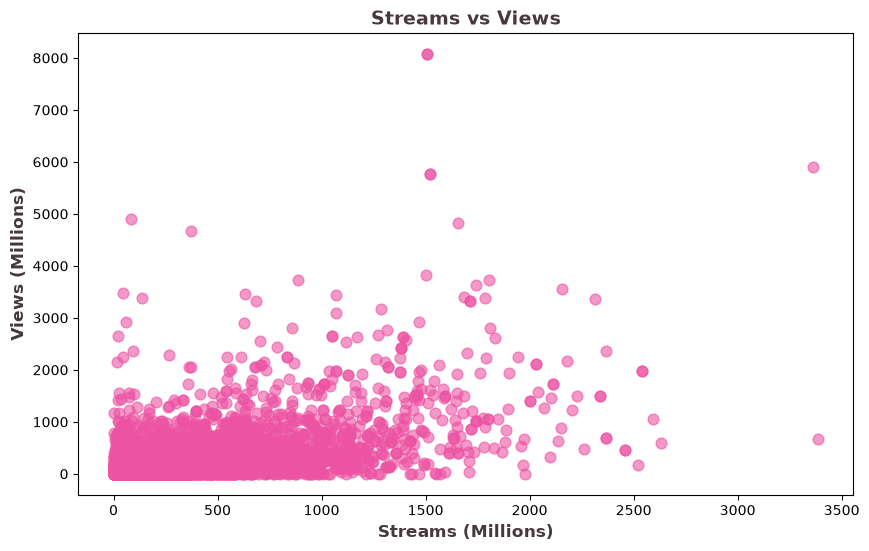

In [76]:
x=df['Streams']
y=df['Views']
plt.figure(figsize=(10,6))
plt.scatter(x,y,color='#ed53a3',
            s=60,
            alpha=0.6)
plt.xlabel('Streams (Millions)',
           fontsize=12,
           fontweight='bold',
           color="#45393f")
plt.ylabel('Views (Millions)',
           fontsize=12,
           fontweight='bold',
           color="#45393f")
plt.title('Streams vs Views',
          fontsize=14,
          fontweight='bold',
          color="#45393f")
plt.show()


### **Bar Chart: Average Views Vs Average Streams By Album**

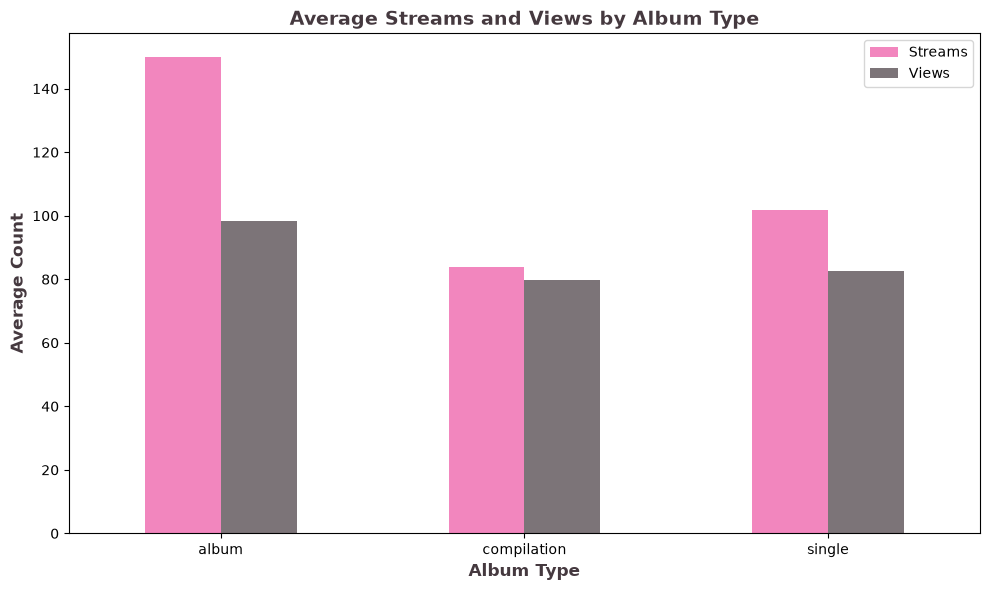

In [77]:
Album=df.groupby('Album_type')[['Streams','Views']].mean()
Album.plot(kind='bar', figsize=(10,6), color=['#ed53a3','#45393f'],alpha=0.7)
plt.title('Average Streams and Views by Album Type',
          fontsize=14,
          fontweight='bold',
          color="#45393f")
plt.xlabel('Album Type',
           fontsize=12,
           fontweight='bold',
           color="#45393f")
plt.xticks(rotation=0)
plt.ylabel('Average Count',
           fontsize=12,
           fontweight='bold',
           color="#45393f")
plt.legend(['Streams', 'Views'])
plt.tight_layout()
plt.show()

### **Bar Plot: Top 10 Most streamed Tracks**

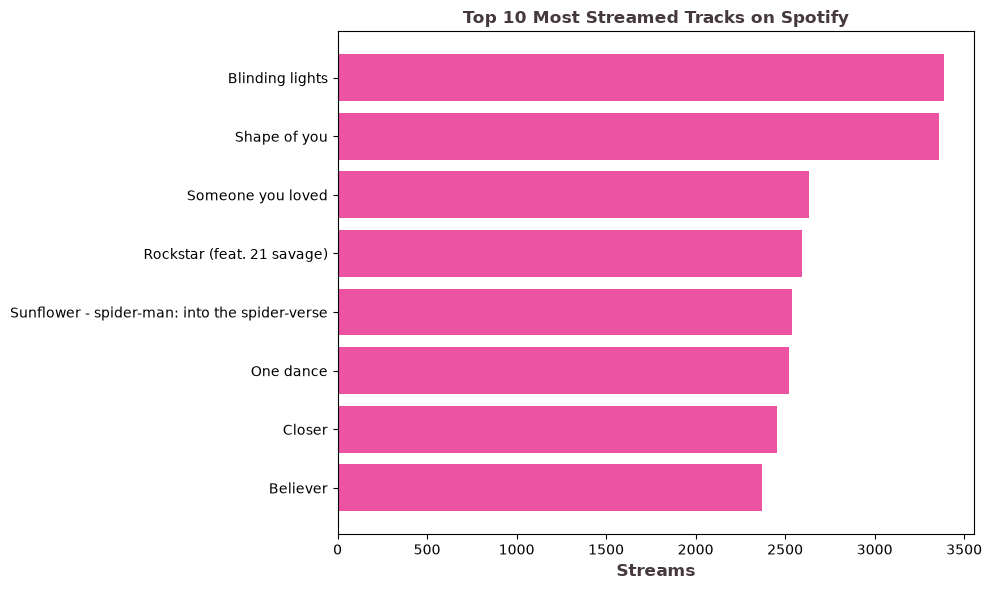

In [78]:
top_10_streams=df.nlargest(10,'Streams')[['Artist','Track','Streams']]
plt.figure(figsize=(10, 6))
plt.barh(top_10_streams['Track'],top_10_streams['Streams'],
         color='#ed53a3')
plt.xlabel('Streams',
           color='#45393f',
           fontsize=12,
           fontweight='bold')
plt.title('Top 10 Most Streamed Tracks on Spotify',
          color='#45393f',
           fontsize=12,
           fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### **Bar Plot: Top 10 Most Viewed Videos**

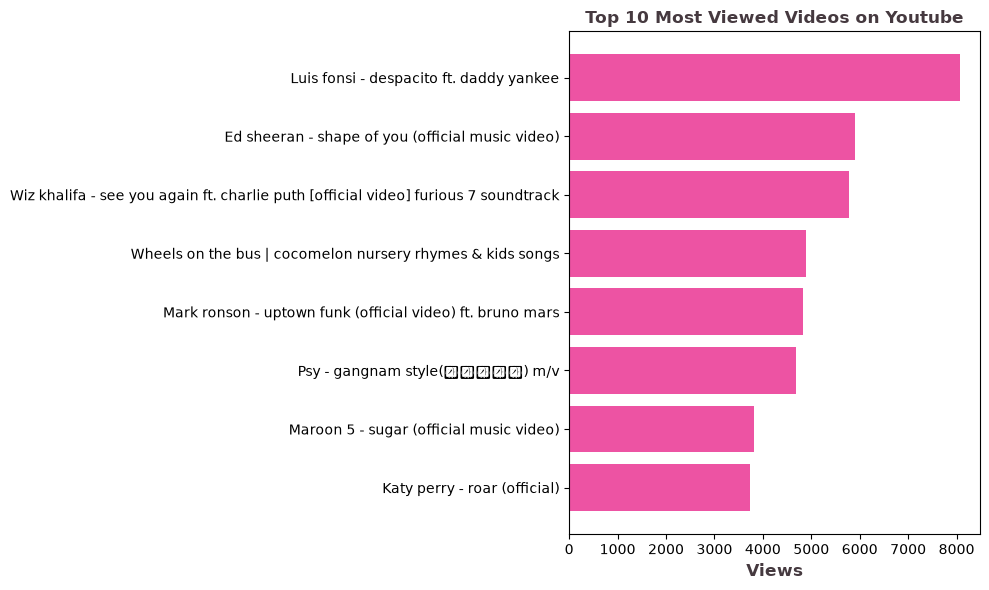

In [100]:
top_10_views=df.nlargest(10,'Views')[['Channel','Title','Views']]
plt.figure(figsize=(10, 6))
plt.barh(top_10_views['Title'],top_10_views['Views'],
         color='#ed53a3')
plt.xlabel('Views',
           color='#45393f',
           fontsize=12,
           fontweight='bold')
plt.title('Top 10 Most Viewed Videos on Youtube',
          color='#45393f',
           fontsize=12,
           fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
import warnings
warnings.filterwarnings('ignore')

### **Pie Chart: Track Distribution by Album Type**

Text(0.5, 1.0, 'Track Distribution by Album Type')

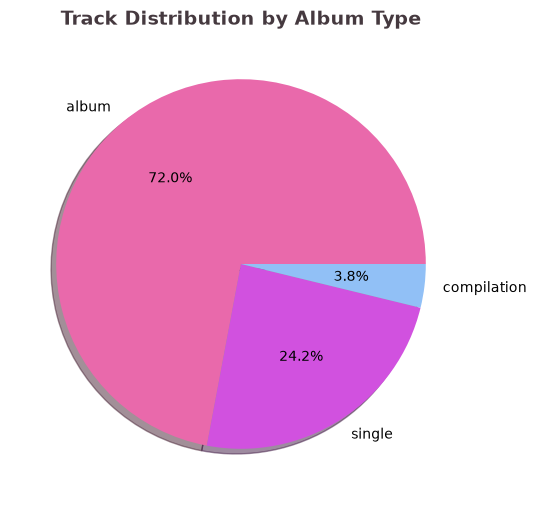

In [112]:
df['Album_type'].value_counts().plot(kind='pie',autopct='%1.1f%%',
                                     colors=["#e969ab","#d151df","#91c0f6"],
                                     figsize=(10,6),
                                     shadow='True')
plt.title('Track Distribution by Album Type',
          color='#45393f',
          fontsize=14,
          fontweight='bold')

### **Heatmap: Audio Features Correlation**

Text(0.5, 1.0, 'Audio Features Correlation')

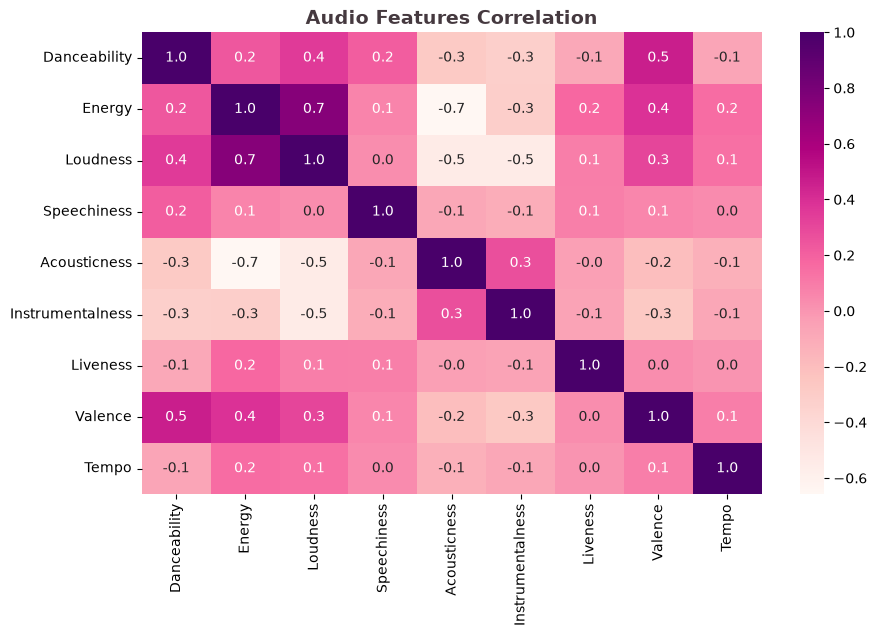

In [111]:
audio_features = ['Danceability', 'Energy', 'Loudness', 'Speechiness',
                  'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo']
plt.figure(figsize=(10,6))
sns.heatmap(df[audio_features].corr(), annot=True, cmap='RdPu', fmt='.1f')
plt.title('Audio Features Correlation',
          fontsize=14,
          fontweight='bold',
          color='#45393f')